In [1]:
from aoespy import *

/home6/afahad/.local/lib/python3.9/site-packages/aoespy.py:19: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [2]:
import xarray as xr

In [3]:
dir='/nobackupp27/afahad/exp/'
data='/nobackupp27/afahad/exp/script_replay_AGU/data/'

In [4]:
cntrl=xr.open_dataset(dir+'GEOSMIT44_cntrl/holding/geosgcm_surf/200506/GEOSMIT44_cntrl.geosgcm_surf.monthly.200506.nc4')
fcast=xr.open_dataset(dir+'GEOSMIT41_ciauF/holding/geosgcm_surf/200506/GEOSMIT41_ciauF.geosgcm_surf.monthly.200506.nc4')

In [9]:
# clim1=xr.open_mfdataset('/nobackupp27/afahad/exp/GEOSMIT44_cntrl/geosgcm_surf/GEOSMIT44_cntrl*.nc4').mean(dim='time').compute()
# clim2=xr.open_mfdataset('/nobackupp27/afahad/exp/GEOSMIT43_free/geosgcm_surf/GEOSMIT43_free*.nc4').mean(dim='time').compute()
# clim3=xr.open_mfdataset('/nobackupp27/afahad/exp/GEOSMIT41_ciauF/geosgcm_surf/GEOSMIT41_ciauF*.nc4').mean(dim='time').compute()

In [10]:
# clim=(clim1+clim2+clim3)/3
# clim=clim.compute()

In [5]:
sst=xr.open_dataset(data+'sst.mon.mean.nc')
sst=sst.assign_coords(lon=(((sst.lon + 180) % 360) - 180)).sortby('lon')

In [6]:
ssta=sst.sst.sel(time='2005-06')

In [7]:
# sst=sst.sst.sel(time=sst['time.month'] == 6)
# sstc=sst.mean(dim='time')
# ssta=ssta-sst.mean(dim='time')

In [8]:
ssta=ssta.interp(lon=cntrl.lon,lat=cntrl.lat)
#sstc=sstc.interp(lon=cntrl.lon,lat=cntrl.lat)

In [11]:
# precip=xr.open_dataset(data+'precip.mon.mean.nc')
# precip=precip.assign_coords(lon=(((precip.lon + 180) % 360) - 180)).sortby('lon')

# precip=precip.interp(lon=cntrl.lon,lat=cntrl.lat)
# precipa=precip.precip.sel(time='2005-06')
# precip=precip.precip.sel(time=precip['time.month'] == 6)
# precipc=precip.mean(dim='time')
# precipa=precipa-precip.mean(dim='time')

In [12]:
# #SST amom
# cntrla=squeeze(cntrl.TS)-squeeze(clim.TS)
# fcasta=squeeze(fcast.TS)-squeeze(clim.TS)


In [13]:
# #PR amom
# cntrlPa=(squeeze(cntrl.PRECTOT)-squeeze(clim.PRECTOT))*86400
# fcastPa=(squeeze(fcast.PRECTOT)-squeeze(clim.PRECTOT))*86400

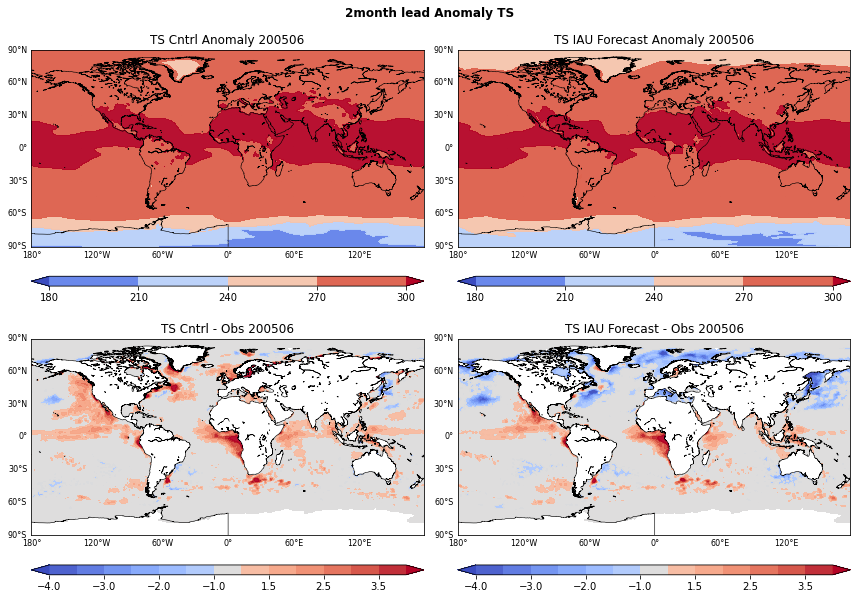

In [30]:
plt.figure(figsize=(12,8.5))
           
clf=array([-4,-3.5,-3,-2.5,-2,-1.5,-1,1,1.5,2,2.5,3,3.5,4])
clf=arange(180,305,30)
plt.suptitle('2month lead Anomaly TS',fontsize=12,fontweight='bold')
plt.subplot(2,2,1)
plot(squeeze(cntrl.TS),clf=clf);
plt.title('TS Cntrl Anomaly 200506')

plt.subplot(2,2,2)
plot(squeeze(fcast.TS),clf=clf);
plt.title('TS IAU Forecast Anomaly 200506')

clf=array([-4,-3.5,-3,-2.5,-2,-1.5,-1,1,1.5,2,2.5,3,3.5,4])

plt.subplot(2,2,3)
plot(squeeze(cntrl.TS_FOUND)-squeeze(ssta)-273.159,clf=clf);
plt.title('TS Cntrl - Obs 200506')

plt.subplot(2,2,4)
plot(squeeze(fcast.TS_FOUND)-squeeze(ssta)-273.159,clf=clf);
plt.title('TS IAU Forecast - Obs 200506')
plt.tight_layout()

#plt.savefig('TS_anom.png',dpi=200)

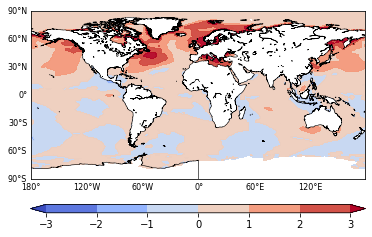

In [31]:
plot(abs(squeeze(cntrl.TS_FOUND)-squeeze(ssta))-abs(squeeze(fcast.TS_FOUND)-squeeze(ssta)),clf=arange(-3,3.1,1));

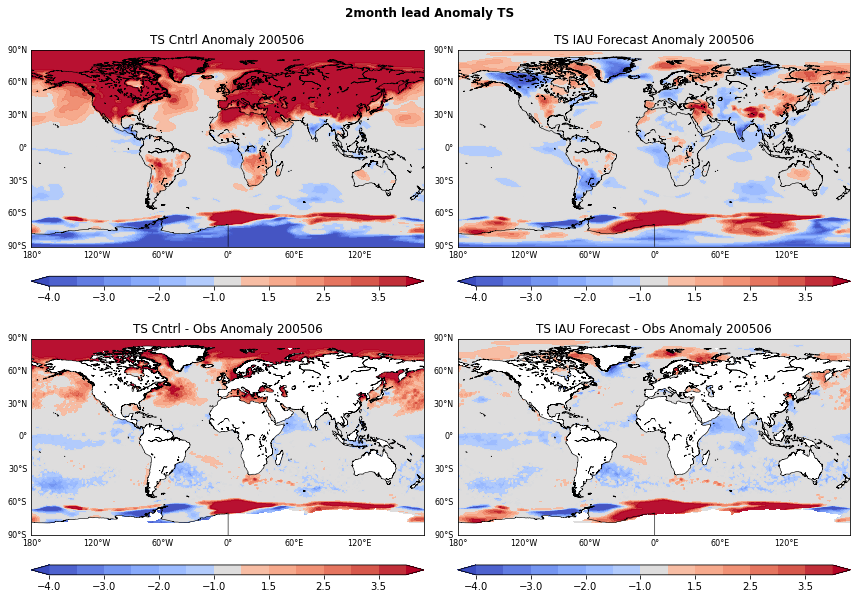

In [14]:
plt.figure(figsize=(12,8.5))
           
clf=array([-4,-3.5,-3,-2.5,-2,-1.5,-1,1,1.5,2,2.5,3,3.5,4])

plt.suptitle('2month lead Anomaly TS',fontsize=12,fontweight='bold')
plt.subplot(2,2,1)
plot(cntrla,clf=clf);
plt.title('TS Cntrl Anomaly 200506')

plt.subplot(2,2,2)
plot(fcasta,clf=clf);
plt.title('TS IAU Forecast Anomaly 200506')



plt.subplot(2,2,3)
plot(cntrla-squeeze(ssta),clf=clf);
plt.title('TS Cntrl - Obs Anomaly 200506')

plt.subplot(2,2,4)
plot(fcasta-squeeze(ssta),clf=clf);
plt.title('TS IAU Forecast - Obs Anomaly 200506')
plt.tight_layout()

#plt.savefig('TS_anom.png',dpi=200)

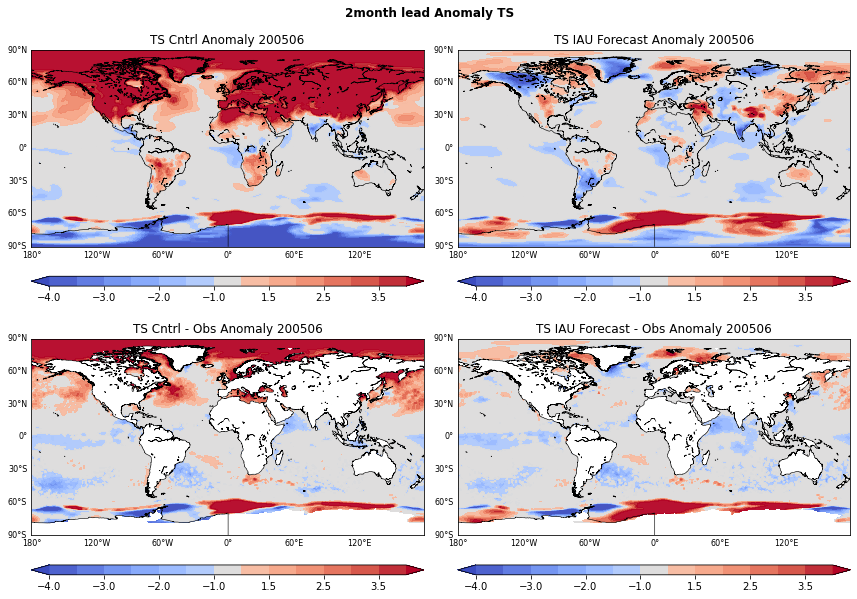

In [12]:
plt.figure(figsize=(12,8.5))
           
clf=array([-4,-3.5,-3,-2.5,-2,-1.5,-1,1,1.5,2,2.5,3,3.5,4])

plt.suptitle('2month lead Anomaly TS',fontsize=12,fontweight='bold')
plt.subplot(2,2,1)
plot(cntrla,clf=clf);
plt.title('TS Cntrl Anomaly 200506')

plt.subplot(2,2,2)
plot(fcasta,clf=clf);
plt.title('TS IAU Forecast Anomaly 200506')



plt.subplot(2,2,3)
plot(cntrla-squeeze(ssta),clf=clf);
plt.title('TS Cntrl - Obs Anomaly 200506')

plt.subplot(2,2,4)
plot(fcasta-squeeze(ssta),clf=clf);
plt.title('TS IAU Forecast - Obs Anomaly 200506')
plt.tight_layout()

#plt.savefig('TS_anom.png',dpi=200)

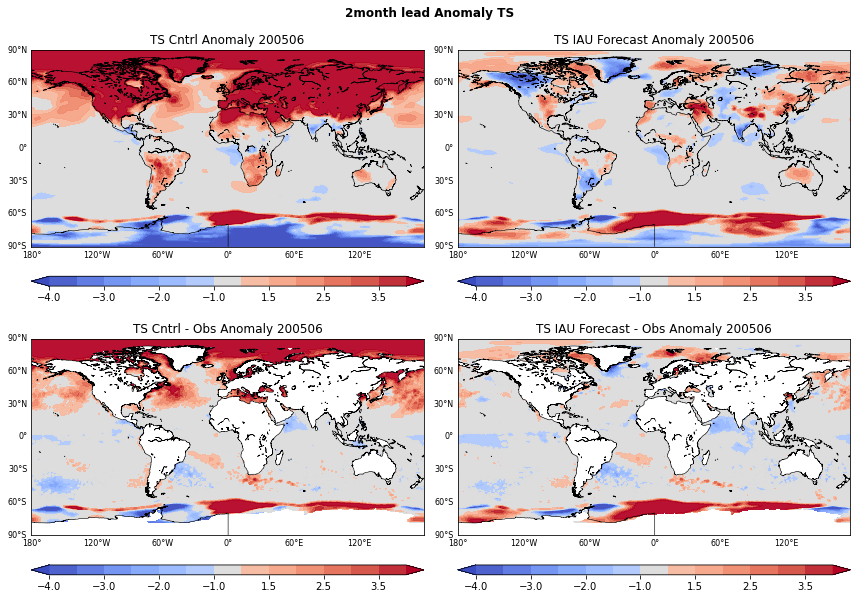

In [20]:
plt.figure(figsize=(12,8.5))
           
clf=array([-4,-3.5,-3,-2.5,-2,-1.5,-1,1,1.5,2,2.5,3,3.5,4])

plt.suptitle('2month lead Anomaly TS',fontsize=12,fontweight='bold')
plt.subplot(2,2,1)
plot(cntrla,clf=clf);
plt.title('TS Cntrl Anomaly 200506')

plt.subplot(2,2,2)
plot(fcasta,clf=clf);
plt.title('TS IAU Forecast Anomaly 200506')



plt.subplot(2,2,3)
plot(cntrla-squeeze(ssta),clf=clf);
plt.title('TS Cntrl - Obs Anomaly 200506')

plt.subplot(2,2,4)
plot(fcasta-squeeze(ssta),clf=clf);
plt.title('TS IAU Forecast - Obs Anomaly 200506')
plt.tight_layout()

plt.savefig('TS_anom.png',dpi=200)

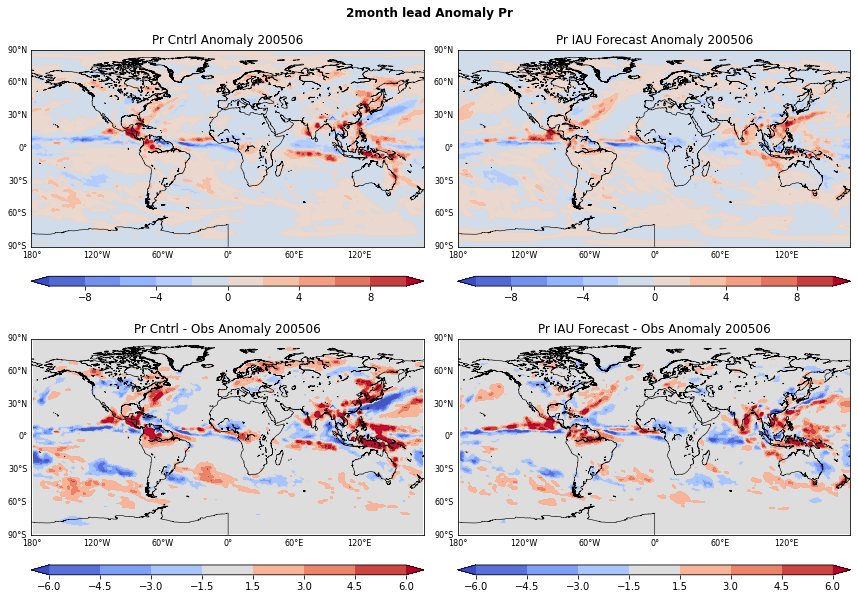

In [21]:
plt.figure(figsize=(12,8.5))
           
clf=arange(-10,11,2)

plt.suptitle('2month lead Anomaly Pr',fontsize=12,fontweight='bold')
plt.subplot(2,2,1)
plot(cntrlPa,clf=clf);
plt.title('Pr Cntrl Anomaly 200506')

plt.subplot(2,2,2)
plot(fcastPa,clf=clf);
plt.title('Pr IAU Forecast Anomaly 200506')

clf=array([-12,-9,-6,-3,3,6,9,12])*.5

plt.subplot(2,2,3)
plot(cntrlPa-squeeze(precipa),clf=clf);
plt.title('Pr Cntrl - Obs Anomaly 200506')

plt.subplot(2,2,4)
plot(fcastPa-squeeze(precipa),clf=clf);
plt.title('Pr IAU Forecast - Obs Anomaly 200506')

plt.tight_layout()
plt.savefig('Pr_anom.png',dpi=200)

In [22]:
pwd

'/nobackupp27/afahad/scripts/initialization_shock'